In [1]:
# os
import os, sys, random

# visualization
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# ml
import numpy as np
import torchvision as tv
import torch
from PIL import Image

# data aug
import copy
import os
import random
import shutil
from collections import defaultdict
from urllib.request import urlretrieve

# helpers
import dataloader as dl
from pathlib import Path
import helpers as hp

sys.path.append('../streaming_base')
#from streaming_base.processing.processing import beamform_2d
from streaming_base.utils.utils import get_ant_pos_2d, plot_2d_polar_heatmap, plot_2d_heatmap
from utils.utility import read_radar_params


%load_ext autoreload
%autoreload 2

In [2]:
# Global Vars
_DEBUG = True
ROOT_DIR = "../../data/"
OUTPUT_DIR = "../submission/"

home_dir = "D:/GitHub/COM-304-Rat-Detection"
data_dir = "data/rat-data/5-5-26/"

json_filename = r"scripts/chirp1"
config_lua_script = r'scripts/1843_config_highres.lua' 

In [ ]:
args, chirp_dict = dl.read_lua_config(home_dir, config_lua_script)

In [6]:
import re

folder = Path(r"../" + data_dir)

pattern = re.compile(r"^(.*)_Raw_\d+\.bin$")


test_names = []
test_raw = []
test_fft = []

for file in folder.glob("*_Raw_*.bin"):
    match = pattern.match(file.name)
    if match:
        test_names.append(match.group(1))

for name in test_names:
    raw, fft = dl.load_radar_capture(name, data_dir, home_dir, json_filename, args)
    test_raw.append(raw)
    test_fft.append(fft)

print(len(test_names))

81


In [8]:
print("FFT shapes:")
for i, fft in enumerate(test_fft):
    print(f"{test_names[i]}: {fft.shape}")

FFT shapes:
jerry_no-pipe_aligned1: (15, 3, 4, 128)
jerry_no-pipe_aligned2: (16, 3, 4, 128)
jerry_no-pipe_aligned3: (12, 3, 4, 128)
jerry_no-pipe_aligned4: (15, 3, 4, 128)
jerry_no-pipe_aligned5: (16, 3, 4, 128)
jerry_no-pipe_aligned: (18, 3, 4, 128)
jerry_no-pipe_lhs1: (16, 3, 4, 128)
jerry_no-pipe_lhs2: (16, 3, 4, 128)
jerry_no-pipe_lhs3: (15, 3, 4, 128)
jerry_no-pipe_lhs4: (18, 3, 4, 128)
jerry_no-pipe_lhs5: (16, 3, 4, 128)
jerry_no-pipe_rhs1: (15, 3, 4, 128)
jerry_no-pipe_rhs2: (16, 3, 4, 128)
jerry_no-pipe_rhs3: (16, 3, 4, 128)
jerry_no-pipe_rhs4: (15, 3, 4, 128)
jerry_no-pipe_rhs5: (15, 3, 4, 128)
jerry_no-pipe_wall_aligned1: (14, 3, 4, 128)
jerry_no-pipe_wall_aligned2: (16, 3, 4, 128)
jerry_no-pipe_wall_aligned3: (16, 3, 4, 128)
jerry_no-pipe_wall_aligned4: (12, 3, 4, 128)
jerry_no-pipe_wall_aligned5: (15, 3, 4, 128)
jerry_no-pipe_wall_lhs1: (16, 3, 4, 128)
jerry_no-pipe_wall_lhs2: (16, 3, 4, 128)
jerry_no-pipe_wall_lhs3: (16, 3, 4, 128)
jerry_no-pipe_wall_lhs4: (16, 3, 4, 128)


Plotting FFTs for all captures...
['jerry_no-pipe_aligned1', 'jerry_no-pipe_aligned2', 'jerry_no-pipe_aligned3', 'jerry_no-pipe_aligned4', 'jerry_no-pipe_aligned5', 'jerry_no-pipe_aligned', 'jerry_no-pipe_lhs1', 'jerry_no-pipe_lhs2', 'jerry_no-pipe_lhs3', 'jerry_no-pipe_lhs4', 'jerry_no-pipe_lhs5', 'jerry_no-pipe_rhs1', 'jerry_no-pipe_rhs2', 'jerry_no-pipe_rhs3', 'jerry_no-pipe_rhs4', 'jerry_no-pipe_rhs5', 'jerry_no-pipe_wall_aligned1', 'jerry_no-pipe_wall_aligned2', 'jerry_no-pipe_wall_aligned3', 'jerry_no-pipe_wall_aligned4', 'jerry_no-pipe_wall_aligned5', 'jerry_no-pipe_wall_lhs1', 'jerry_no-pipe_wall_lhs2', 'jerry_no-pipe_wall_lhs3', 'jerry_no-pipe_wall_lhs4', 'jerry_no-pipe_wall_lhs5', 'jerry_no-pipe_wall_rhs1', 'jerry_no-pipe_wall_rhs2', 'jerry_no-pipe_wall_rhs3', 'jerry_no-pipe_wall_rhs4', 'jerry_no-pipe_wall_rhs5', 'jerry_pipe_1', 'jerry_pipe_2', 'jerry_pipe_3', 'jerry_pipe_4', 'jerry_pipe_5', 'jerry_pipe_lhs1', 'jerry_pipe_lhs2', 'jerry_pipe_lhs3', 'jerry_pipe_lhs4', 'jerry_pi

C:\Users\janva\AppData\Local\Temp\ipykernel_9896\3928807561.py:15: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


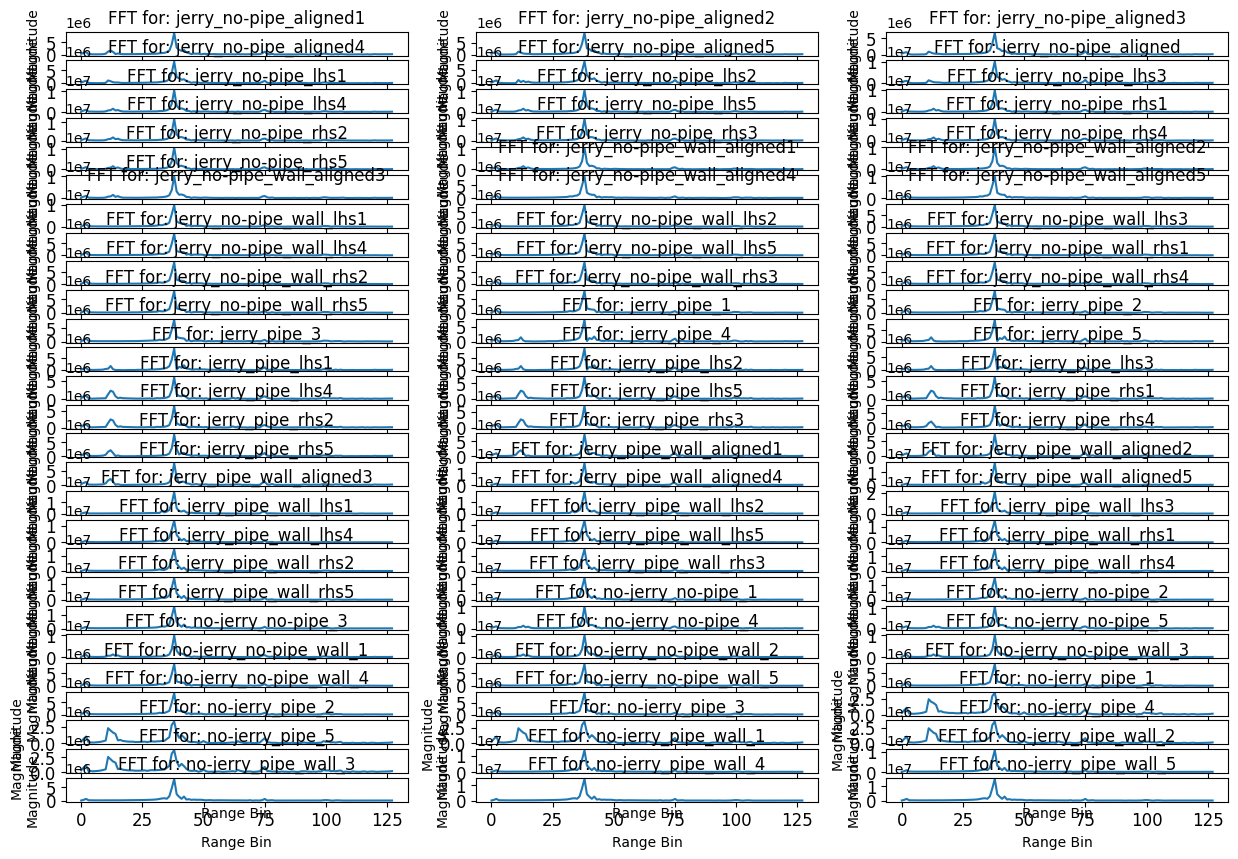

In [10]:
fig, axs = plt.subplots(len(test_names) // 3 + (len(test_fft) % 3 > 0), 3, figsize=(15, 10))
print("Plotting FFTs for all captures...")
print(test_names)

for i, fft in enumerate(test_fft):
    ax = axs[i // 3, i % 3]  # convert index → grid position
    signal = abs(np.squeeze(np.sum(fft, axis=(0,2,1))))
    ax.plot(signal)
    ax.set_title(f"FFT for: {test_names[i]}")
    ax.set_xlabel('Range Bin')
    ax.set_ylabel('Magnitude')
    ax.fontsize = 8
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()

In [ ]:
jerry_pos = ['no-jerry', 'aligned', 'lhs', 'rhs']
experiment = ['pipe', 'no-pipe', 'pipe_wall', 'no-pipe_wall']

print(test_names)

from collections import defaultdict

import re
import numpy as np

groups = defaultdict(list)

def strip_run_number(name):
    # removes trailing digits like ..._1, ..._12
    return re.sub(r'\d+$', '', name)

for fft, name in zip(test_fft, test_names):
    base_name = strip_run_number(name)
    groups[base_name].append(fft)

print("Groups found:")
for key in groups:
    print(f"{key}: {len(groups[key])} captures")

['jerry_no-pipe_aligned1', 'jerry_no-pipe_aligned2', 'jerry_no-pipe_aligned3', 'jerry_no-pipe_aligned4', 'jerry_no-pipe_aligned5', 'jerry_no-pipe_aligned', 'jerry_no-pipe_lhs1', 'jerry_no-pipe_lhs2', 'jerry_no-pipe_lhs3', 'jerry_no-pipe_lhs4', 'jerry_no-pipe_lhs5', 'jerry_no-pipe_rhs1', 'jerry_no-pipe_rhs2', 'jerry_no-pipe_rhs3', 'jerry_no-pipe_rhs4', 'jerry_no-pipe_rhs5', 'jerry_no-pipe_wall_aligned1', 'jerry_no-pipe_wall_aligned2', 'jerry_no-pipe_wall_aligned3', 'jerry_no-pipe_wall_aligned4', 'jerry_no-pipe_wall_aligned5', 'jerry_no-pipe_wall_lhs1', 'jerry_no-pipe_wall_lhs2', 'jerry_no-pipe_wall_lhs3', 'jerry_no-pipe_wall_lhs4', 'jerry_no-pipe_wall_lhs5', 'jerry_no-pipe_wall_rhs1', 'jerry_no-pipe_wall_rhs2', 'jerry_no-pipe_wall_rhs3', 'jerry_no-pipe_wall_rhs4', 'jerry_no-pipe_wall_rhs5', 'jerry_pipe_1', 'jerry_pipe_2', 'jerry_pipe_3', 'jerry_pipe_4', 'jerry_pipe_5', 'jerry_pipe_lhs1', 'jerry_pipe_lhs2', 'jerry_pipe_lhs3', 'jerry_pipe_lhs4', 'jerry_pipe_lhs5', 'jerry_pipe_rhs1', 'jerr

In [39]:
def reduce_capture(fft):
    fft = np.asarray(fft)

    # average over time (frames)
    fft = np.mean(fft, axis=0)      # (3,4,128)

    # collapse antenna + doppler → range profile
    sig = np.abs(np.sum(fft, axis=(0,1)))  # (128,)

    return sig

combined_signals = {}
for key, ff_list in groups.items():
    print(f"Processing group: {key} with {len(ff_list)} captures")
    
    # average signals for all captures in this group
    signals = []
    for fft in ff_list:
        sig = reduce_capture(fft)
        signals.append(sig)
    
    combined_signal = np.mean(signals, axis=0)
    combined_signals[key] = combined_signal

print("Combined signals for groups:")
for key in combined_signals:
    print(f"{key}: {combined_signals[key].shape}")

# print a single example of the combined signal
example_key = list(combined_signals.keys())[0]
print(f"Example combined signal for group '{example_key}':")
print(combined_signals[example_key])

Processing group: jerry_no-pipe_aligned with 6 captures
Processing group: jerry_no-pipe_lhs with 5 captures
Processing group: jerry_no-pipe_rhs with 5 captures
Processing group: jerry_no-pipe_wall_aligned with 5 captures
Processing group: jerry_no-pipe_wall_lhs with 5 captures
Processing group: jerry_no-pipe_wall_rhs with 5 captures
Processing group: jerry_pipe_ with 5 captures
Processing group: jerry_pipe_lhs with 5 captures
Processing group: jerry_pipe_rhs with 5 captures
Processing group: jerry_pipe_wall_aligned with 5 captures
Processing group: jerry_pipe_wall_lhs with 5 captures
Processing group: jerry_pipe_wall_rhs with 5 captures
Processing group: no-jerry_no-pipe_ with 5 captures
Processing group: no-jerry_no-pipe_wall_ with 5 captures
Processing group: no-jerry_pipe_ with 5 captures
Processing group: no-jerry_pipe_wall_ with 5 captures
Combined signals for groups:
jerry_no-pipe_aligned: (128,)
jerry_no-pipe_lhs: (128,)
jerry_no-pipe_rhs: (128,)
jerry_no-pipe_wall_aligned: (128

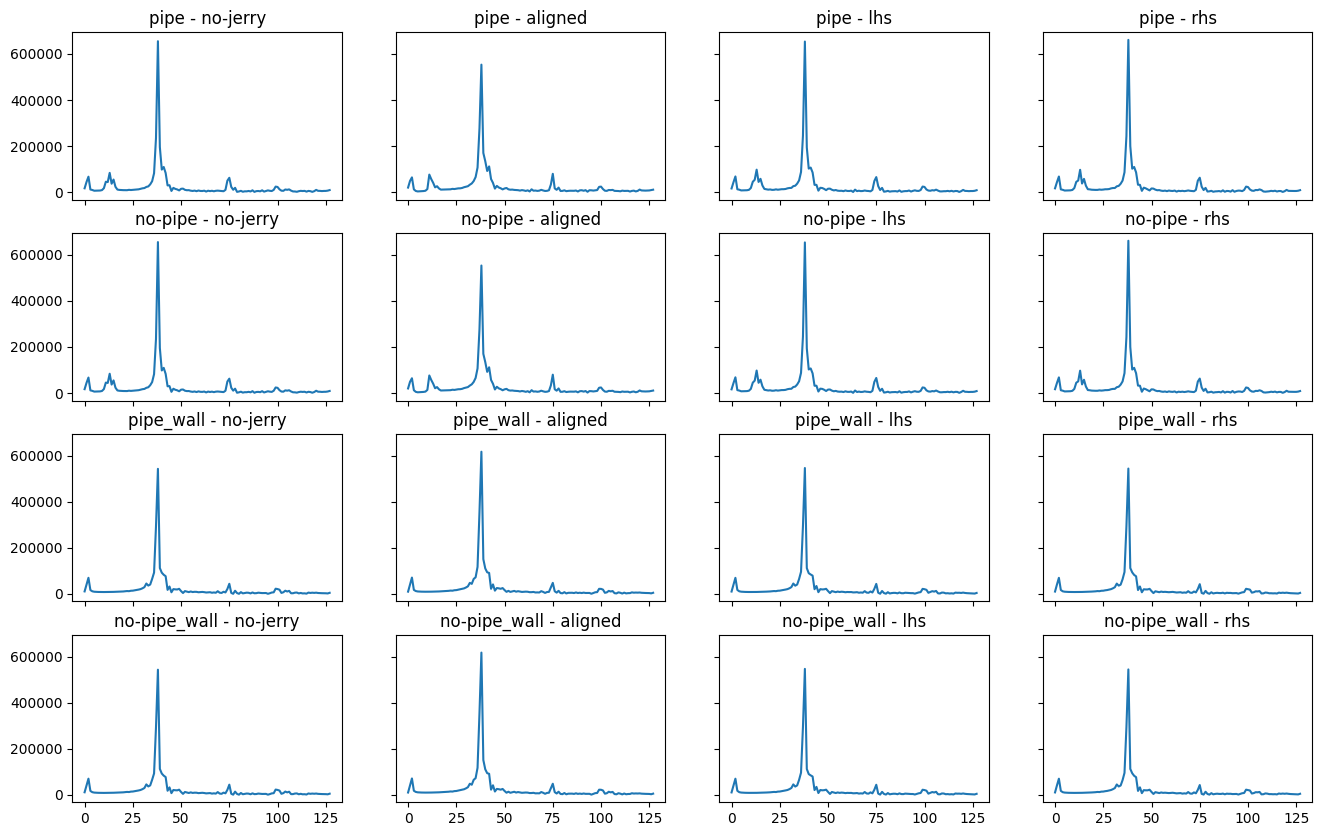

In [41]:
fig, axs = plt.subplots(
    len(experiment),
    len(jerry_pos),
    figsize=(16, 10),
    sharex=True,
    sharey=True
)

for i, exp in enumerate(experiment):
    for j, pos in enumerate(jerry_pos):

        ax = axs[i, j]

        # build SAME key format as dictionary
        matches = [k for k in combined_signals if exp in k and pos in k]

        if len(matches) > 0:
            ax.plot(combined_signals[matches[0]])
        else:
            ax.text(0.5, 0.5, 'No data',
                    ha='center', va='center')

        ax.set_title(f"{exp} - {pos}")

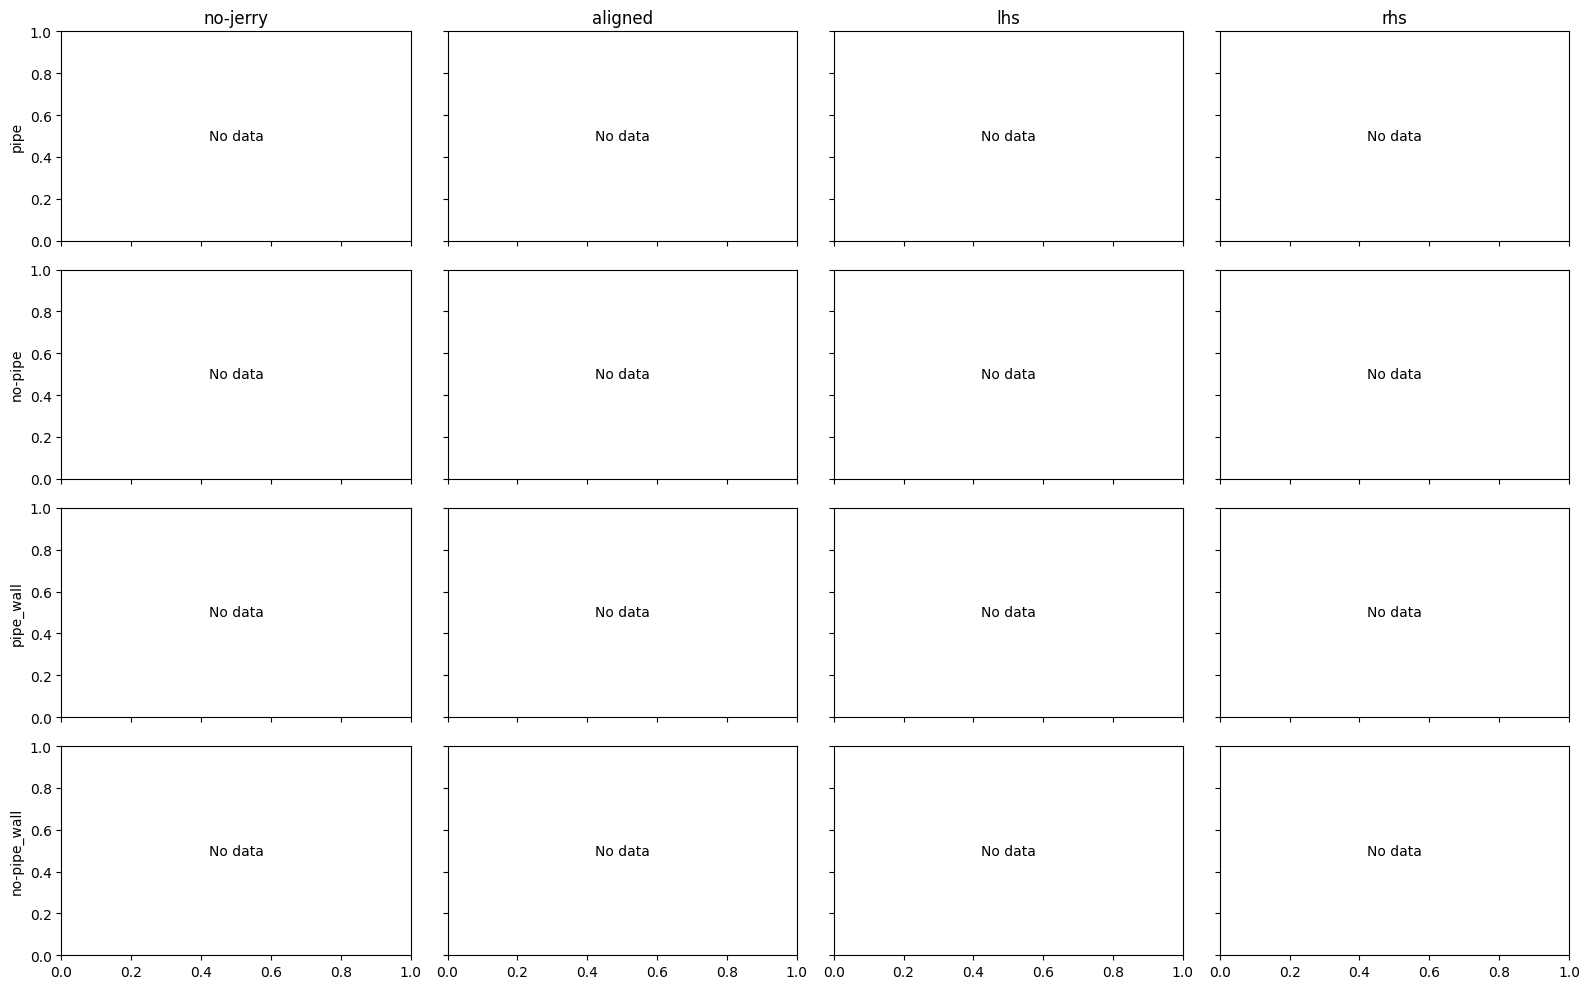

In [36]:
fig, axs = plt.subplots(
    len(experiment),
    len(jerry_pos),
    figsize=(16, 10),
    sharex=True,
    sharey=True
)

for i, exp in enumerate(experiment):
    for j, pos in enumerate(jerry_pos):

        ax = axs[i, j]
        key = (exp, pos)

        if key in combined_signals:
            ax.plot(combined_signals[key])
        else:
            ax.text(0.5, 0.5, 'No data',
                    ha='center', va='center')

        # labels
        if i == 0:
            ax.set_title(pos)
        if j == 0:
            ax.set_ylabel(exp)

plt.tight_layout()
plt.show()

In [42]:
def get_signal(exp, pos):
    for k in combined_signals:
        if exp in k and pos in k:
            return combined_signals[k]
    return None

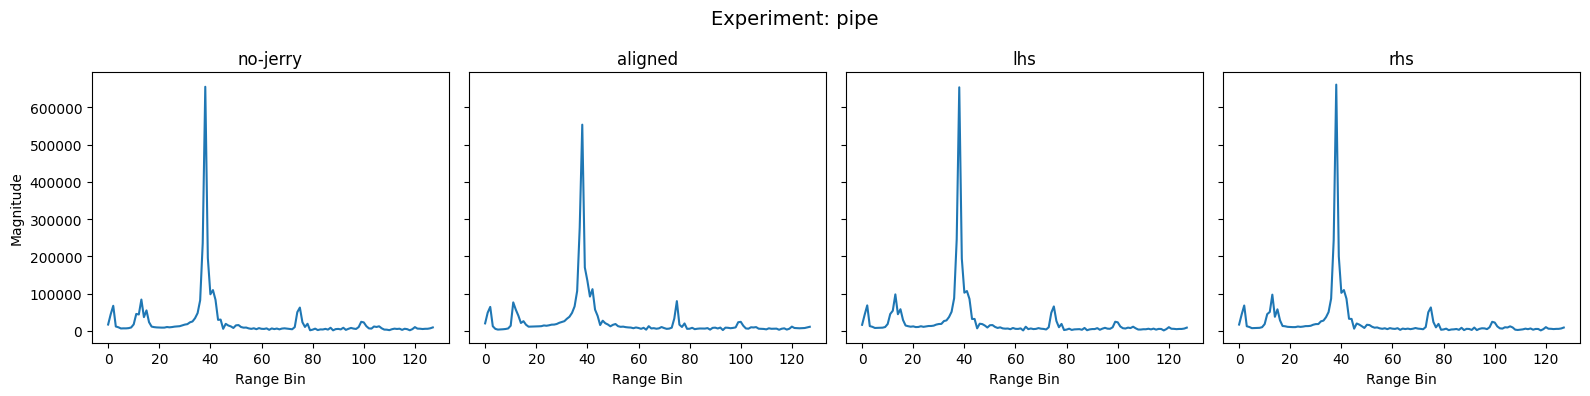

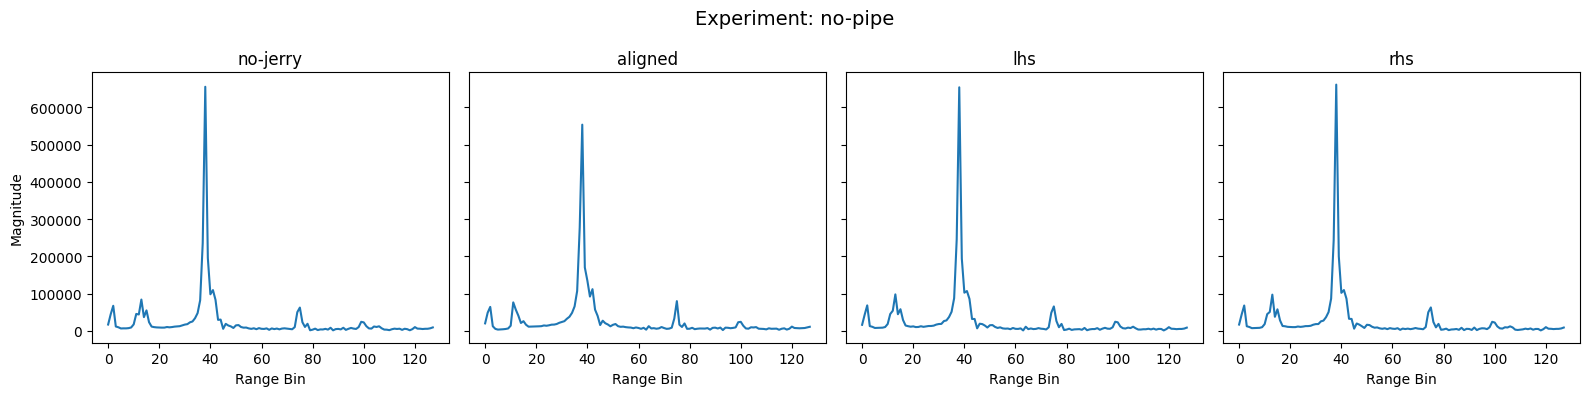

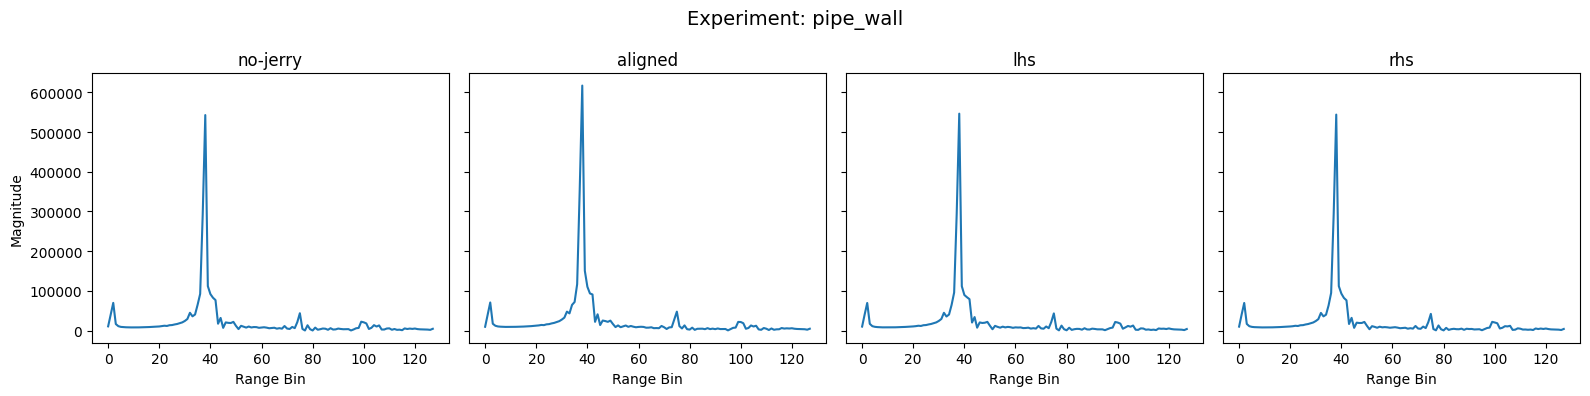

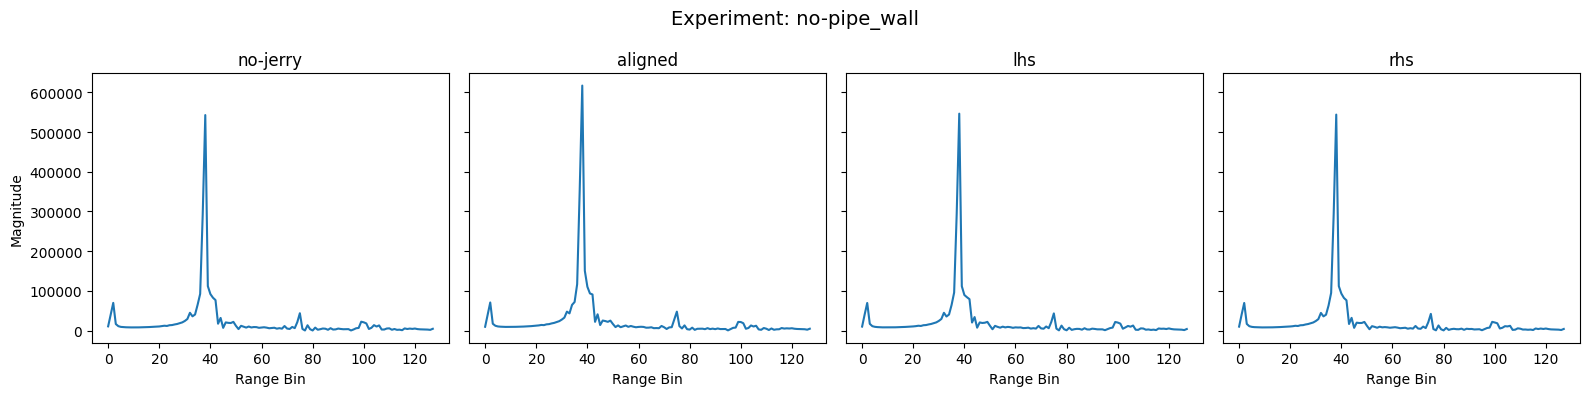

In [44]:
for exp in experiment:

    fig, axs = plt.subplots(
        1,
        len(jerry_pos),
        figsize=(16, 4),
        sharey=True
    )

    fig.suptitle(f"Experiment: {exp}", fontsize=14)

    for j, pos in enumerate(jerry_pos):

        ax = axs[j]

        sig = get_signal(exp, pos)

        if sig is not None:
            ax.plot(sig)
        else:
            ax.text(0.5, 0.5, 'No data',
                    ha='center', va='center')

        ax.set_title(pos)
        ax.set_xlabel("Range Bin")

        if j == 0:
            ax.set_ylabel("Magnitude")

    plt.tight_layout()
    plt.show()